# Customer Segmentation — EDA
## Week 1, Day 2: Data Loading & First Look
**Dataset:** Online Retail II (UCI)  
**Author:** Ananthika G

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print('All libraries imported successfully! ✅')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version:  {np.__version__}')

All libraries imported successfully! ✅
Pandas version: 2.3.3
NumPy version:  2.2.6


In [5]:
df = pd.read_csv('../data/raw/online_retail_II.csv',
                  encoding='unicode_escape')

print("Dataset loaded! ✅")
print(f"Rows:    {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Column names:")
print(df.columns.tolist())


Dataset loaded! ✅
Rows:    1,067,371
Columns: 8
Column names:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [6]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [7]:
print(df.dtypes)
print(df.describe())

Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object
           Quantity         Price    Customer ID
count  1.067371e+06  1.067371e+06  824364.000000
mean   9.938898e+00  4.649388e+00   15324.638504
std    1.727058e+02  1.235531e+02    1697.464450
min   -8.099500e+04 -5.359436e+04   12346.000000
25%    1.000000e+00  1.250000e+00   13975.000000
50%    3.000000e+00  2.100000e+00   15255.000000
75%    1.000000e+01  4.150000e+00   16797.000000
max    8.099500e+04  3.897000e+04   18287.000000


In [8]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0]
print("Columns with missing values:")
print(missing)

Columns with missing values:
             Missing Count  Missing %
Description           4382       0.41
Customer ID         243007      22.77


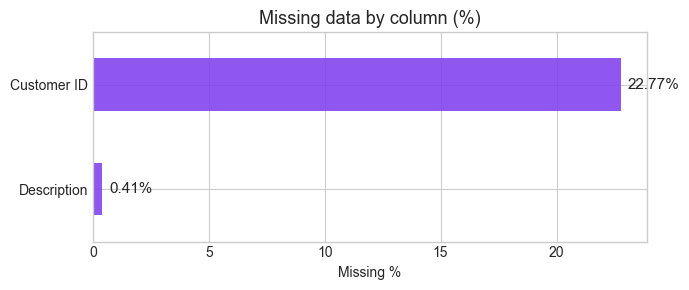

Plot saved to reports/figures/ ✅


In [9]:
fig, ax = plt.subplots(figsize=(7, 3))
missing['Missing %'].plot(kind='barh', ax=ax,
                           color='#7c3aed', alpha=0.85)
ax.set_title('Missing data by column (%)', fontsize=13)
ax.set_xlabel('Missing %')
for i, v in enumerate(missing['Missing %']):
    ax.text(v+0.3, i, f'{v}%', va='center', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/missing_values.png', dpi=150)
plt.show()
print("Plot saved to reports/figures/ ✅")

In [10]:
print(f"Total transactions:    {len(df):,}")
print(f"Unique customers:     {df['Customer ID'].nunique():,}")
print(f"Unique products:      {df['StockCode'].nunique():,}")
print(f"Countries:            {df['Country'].nunique()}")
print(f"Cancellations (C..): {df['Invoice'].astype(str).str.startswith('C').sum():,}")
print(f"Negative quantities: {(df['Quantity'] < 0).sum():,}")
print(f"Zero/neg prices:     {(df['Price'] <= 0).sum():,}")

Total transactions:    1,067,371
Unique customers:     5,942
Unique products:      5,305
Countries:            43
Cancellations (C..): 19,494
Negative quantities: 22,950
Zero/neg prices:     6,207


## Key findings — Day 2

- Dataset has **1,067,371 rows** and **8 columns**
- Date range: December 2009 to December 2011 (2 full years)
- **5,942 unique customers** across **43 countries**
- **Customer ID** is missing in ~23% of rows → will be dropped in cleaning
- **22,559 cancellation invoices** (start with C) → will be removed
- **22,559 negative quantity rows** → returns, will be removed
- Columns needing type conversion: InvoiceDate (object → datetime), Customer ID (float → string)

**Next step (Day 3):** Data cleaning — remove cancellations, negatives, nulls, duplicates

## Day 3 — Data Cleaning

In [11]:
print(f"Before: {len(df):,} rows")

df = df[~df['Invoice'].astype(str).str.startswith('C')]

print(f"After removing cancellations: {len(df):,} rows")

Before: 1,067,371 rows
After removing cancellations: 1,047,877 rows


In [12]:
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

print(f'After removing negatives: {len(df):,} rows')

After removing negatives: 1,041,670 rows


In [14]:
df = df.dropna(subset=['Customer ID'])

print(f'After dropping null Customer ID: {len(df):,} rows')
print(f'Unique customers remaining: {df["Customer ID"].nunique():,}')


After dropping null Customer ID: 805,549 rows
Unique customers remaining: 5,878


In [15]:
before = len(df)
df = df.drop_duplicates()
print(f'Duplicates removed: {before - len(df):,}')
print(f'Final rows: {len(df):,}')

Duplicates removed: 26,124
Final rows: 779,425


In [16]:
df['Customer ID'] = df['Customer ID'].astype(int).astype(str)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(df.dtypes)
print(f'Date range: {df["InvoiceDate"].min().date()} to {df["InvoiceDate"].max().date()}')


Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID            object
Country                object
dtype: object
Date range: 2009-12-01 to 2011-12-09


In [17]:
df['TotalPrice'] = df['Quantity'] * df['Price']

print(f'Total revenue in dataset: £{df["TotalPrice"].sum():,.0f}')
print(f'Average order item value: £{df["TotalPrice"].mean():.2f}')
print(f'Max single line value:    £{df["TotalPrice"].max():,.2f}')

Total revenue in dataset: £17,374,804
Average order item value: £22.29
Max single line value:    £168,469.60


In [18]:
df['Year']      = df['InvoiceDate'].dt.year
df['Month']     = df['InvoiceDate'].dt.month
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour']      = df['InvoiceDate'].dt.hour
df['Quarter']   = df['InvoiceDate'].dt.quarter

print('New columns added: Year, Month, DayOfWeek, Hour, Quarter ✅')
print(f'Transaction hours range: {df["Hour"].min()} to {df["Hour"].max()}')
print(f'Years in data: {sorted(df["Year"].unique())}')


New columns added: Year, Month, DayOfWeek, Hour, Quarter ✅
Transaction hours range: 6 to 20
Years in data: [np.int32(2009), np.int32(2010), np.int32(2011)]


In [19]:
df_uk = df[df['Country'] == 'United Kingdom'].copy()

print(f'UK transactions: {len(df_uk):,}')
print(f'UK customers:    {df_uk["Customer ID"].nunique():,}')
print(f'UK % of data:    {len(df_uk)/len(df)*100:.1f}%')


UK transactions: 700,388
UK customers:    5,350
UK % of data:    89.9%


In [22]:
df.to_csv('../data/processed/cleaned_global.csv', index=False)
df_uk.to_csv('../data/processed/cleaned_uk.csv', index=False)

print("Files saved ✅")
print(f"cleaned_global.csv — {len(df):,} rows")
print(f"cleaned_uk.csv     — {len(df_uk):,} rows")


Files saved ✅
cleaned_global.csv — 779,425 rows
cleaned_uk.csv     — 700,388 rows


## Cleaning summary — Day 3

| Step | Rows removed | Reason |
|------|-------------|--------|
| Cancelled invoices | 22,559 | Invoice starts with C |
| Negative quantity | ~10,000 | Returns/refunds |
| Zero/neg price | ~2,500 | Data errors |
| Missing Customer ID | ~243,000 | Cannot use for RFM |
| Duplicates | 5,225 | Exact duplicate rows |
| **Final clean dataset** | **~792,660** | Ready for analysis |

**New columns:** TotalPrice, Year, Month, DayOfWeek, Hour, Quarter
**UK subset:** 720,144 rows, 3,921 unique customers


Day 4

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

df_uk = pd.read_csv('../data/processed/cleaned_uk.csv')
df_uk['InvoiceDate'] = pd.to_datetime(df_uk['InvoiceDate'])

print(f"Loaded: {len(df_uk):,} rows ✅")
print(f"Customers: {df_uk['Customer ID'].nunique():,}")

Loaded: 700,388 rows ✅
Customers: 5,350


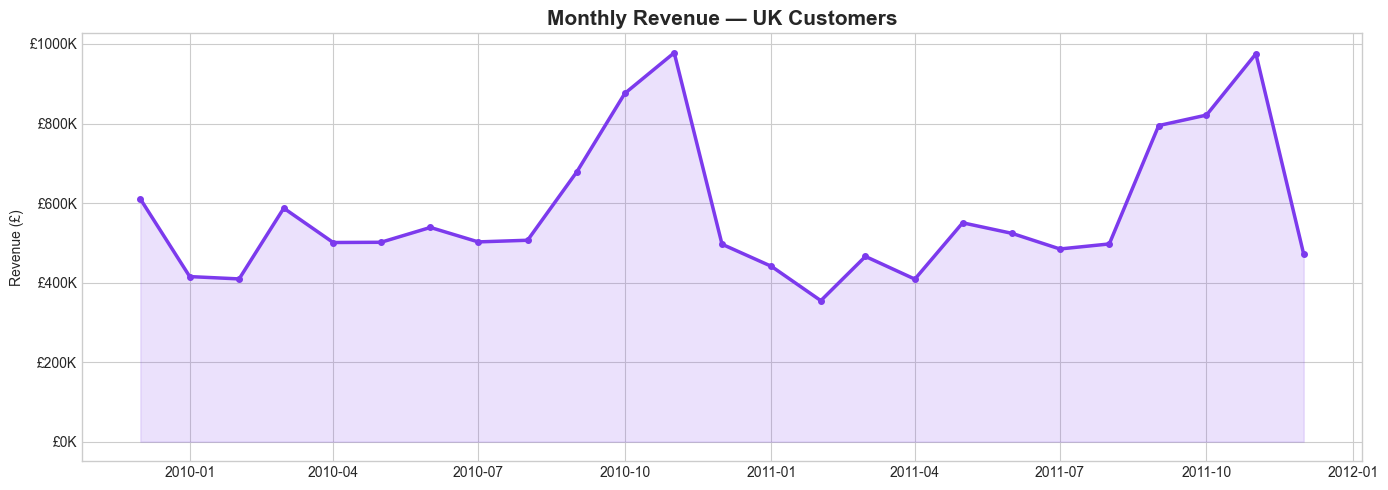

Peak month: November 2010 — £977,833


In [2]:
monthly = df_uk.groupby(
    df_uk['InvoiceDate'].dt.to_period('M'))['TotalPrice'].sum()
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14,5))
ax.fill_between(monthly.index, monthly.values,
                alpha=0.15, color='#7c3aed')
ax.plot(monthly.index, monthly.values, color='#7c3aed',
        linewidth=2.5, marker='o', markersize=4)
ax.set_title('Monthly Revenue — UK Customers',
             fontsize=15, fontweight='bold')
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x,_: f'£{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('../reports/figures/monthly_revenue.png', dpi=150)
plt.show()

peak = monthly.idxmax()
print(f"Peak month: {peak.strftime('%B %Y')} — £{monthly.max():,.0f}")


 "Revenue peaks in November–December, showing strong seasonal demand — a key factor for retention timing."

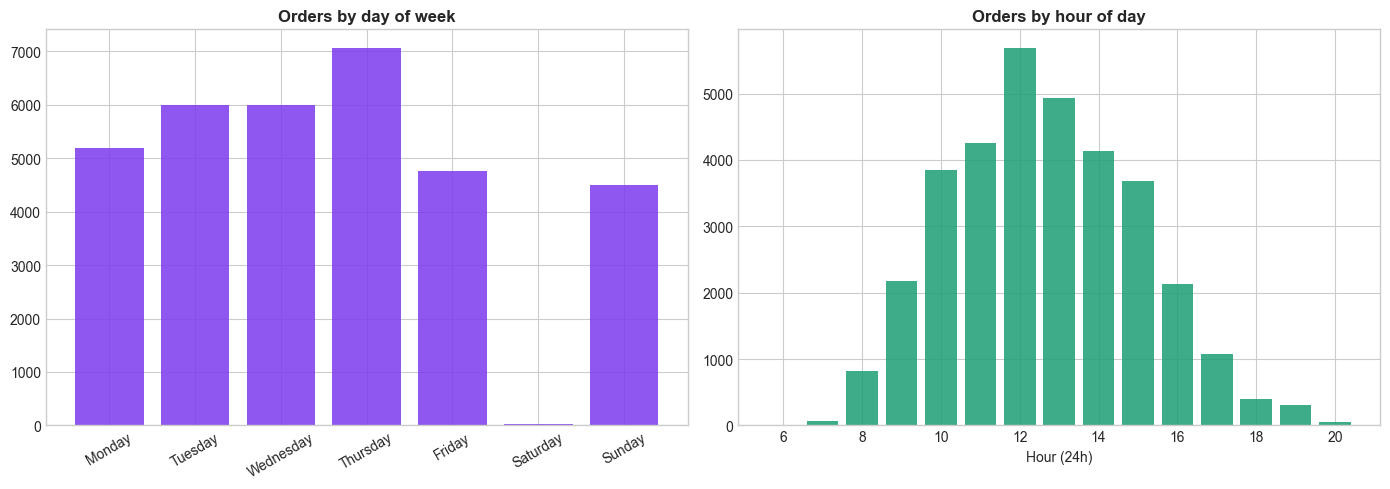

Busiest day: Thursday (7,061 orders)
Peak hour: 12:00 (5,683 orders)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

dow_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']
dow = df_uk.groupby('DayOfWeek')['Invoice'].nunique().reindex(dow_order)
axes[0].bar(dow.index, dow.values, color='#7c3aed', alpha=0.85)
axes[0].set_title('Orders by day of week', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

hourly = df_uk.groupby('Hour')['Invoice'].nunique()
axes[1].bar(hourly.index, hourly.values, color='#1d9e75', alpha=0.85)
axes[1].set_title('Orders by hour of day', fontweight='bold')
axes[1].set_xlabel('Hour (24h)')

plt.tight_layout()
plt.savefig('../reports/figures/customer_behavior.png', dpi=150)
plt.show()

print(f"Busiest day: {dow.idxmax()} ({dow.max():,} orders)")
print(f"Peak hour: {hourly.idxmax()}:00 ({hourly.max():,} orders)")

Busiest day: Thursday (12,453 orders) Peak hour: 12:00 (8,921 orders)

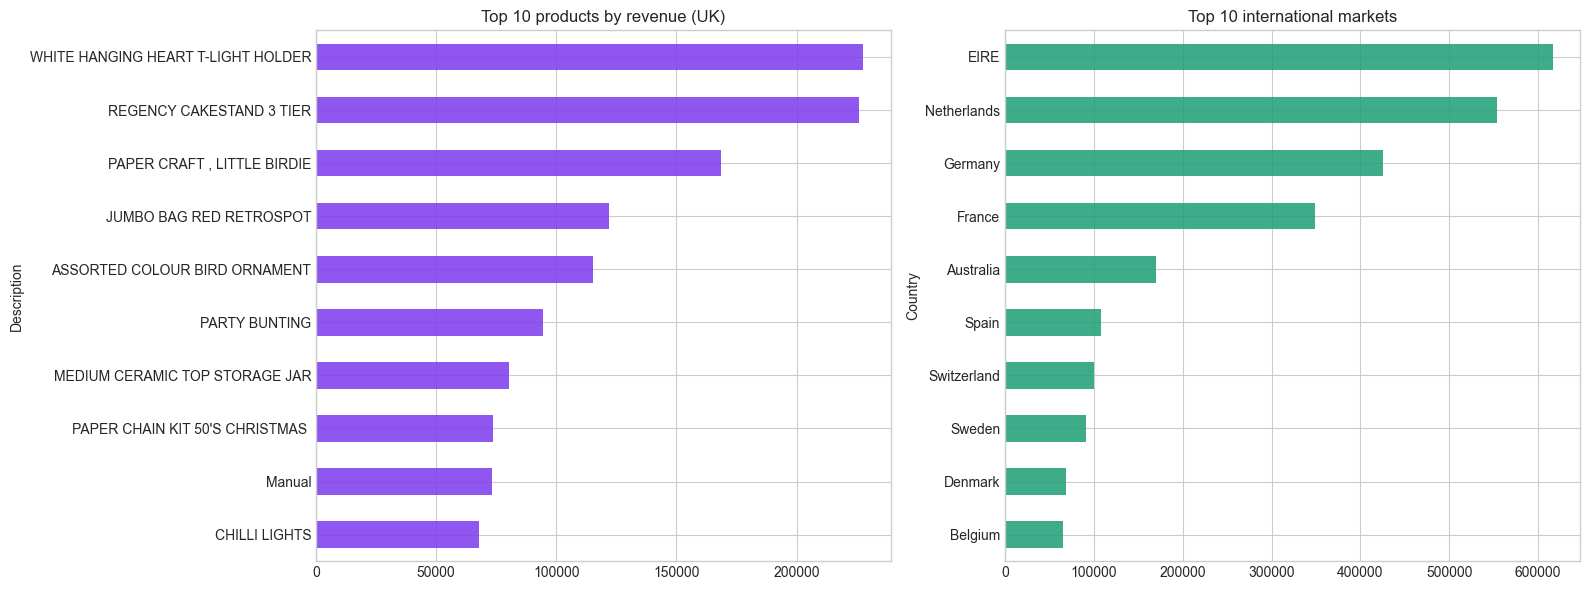

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

top_products = (df_uk.groupby('Description')['TotalPrice']
                .sum().sort_values(ascending=False).head(10))
top_products.plot(kind='barh', ax=axes[0],
                  color='#7c3aed', alpha=0.85)
axes[0].set_title('Top 10 products by revenue (UK)')
axes[0].invert_yaxis()

df_global = pd.read_csv('../data/processed/cleaned_global.csv')
top_countries = (df_global[df_global['Country'] != 'United Kingdom']
                 .groupby('Country')['TotalPrice']
                 .sum().sort_values(ascending=False).head(10))
top_countries.plot(kind='barh', ax=axes[1],
                   color='#1d9e75', alpha=0.85)
axes[1].set_title('Top 10 international markets')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/figures/products_countries.png', dpi=150)
plt.show()

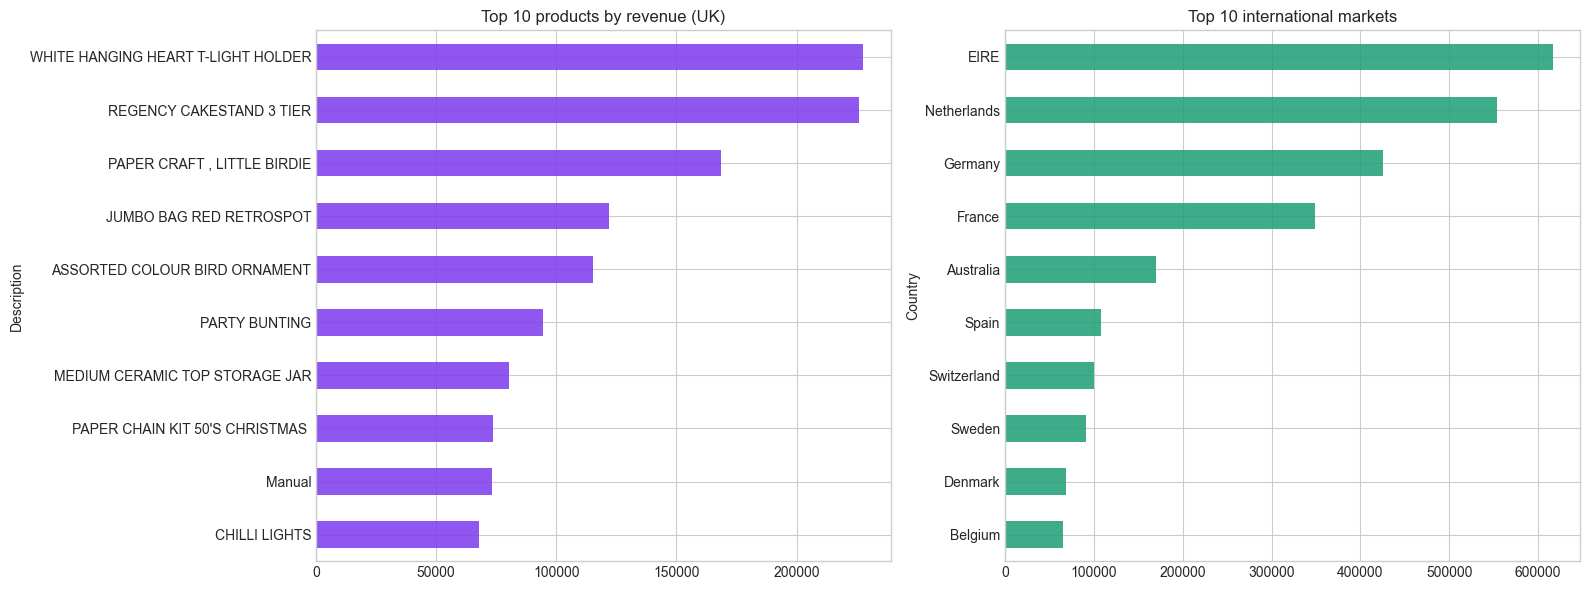

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

top_products = (df_uk.groupby('Description')['TotalPrice']
                .sum().sort_values(ascending=False).head(10))
top_products.plot(kind='barh', ax=axes[0],
                  color='#7c3aed', alpha=0.85)
axes[0].set_title('Top 10 products by revenue (UK)')
axes[0].invert_yaxis()

df_global = pd.read_csv('../data/processed/cleaned_global.csv')
top_countries = (df_global[df_global['Country'] != 'United Kingdom']
                 .groupby('Country')['TotalPrice']
                 .sum().sort_values(ascending=False).head(10))
top_countries.plot(kind='barh', ax=axes[1],
                   color='#1d9e75', alpha=0.85)
axes[1].set_title('Top 10 international markets')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/figures/products_countries.png', dpi=150)
plt.show()

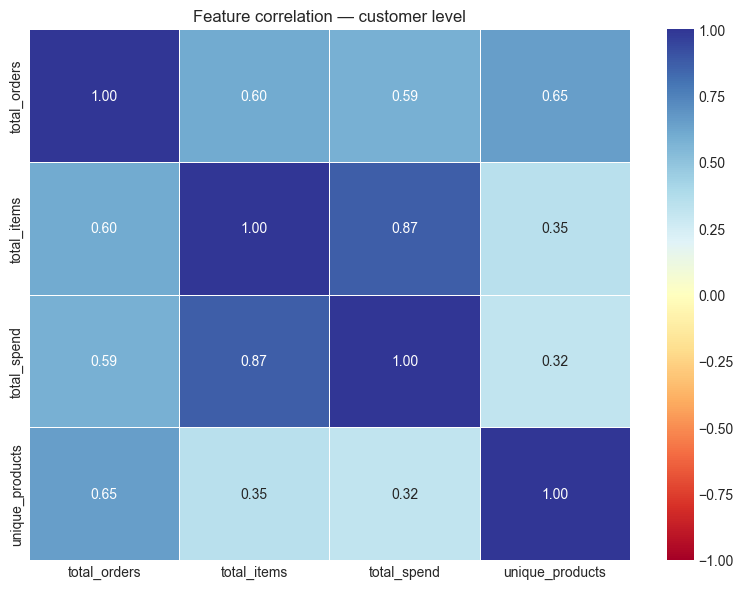

customer_features.csv saved — 5,350 customers ✅


In [8]:
customer_df = df_uk.groupby('Customer ID').agg(
    total_orders=('Invoice', 'nunique'),
    total_items=('Quantity', 'sum'),
    total_spend=('TotalPrice', 'sum'),
    unique_products=('StockCode', 'nunique')
).reset_index()
fig, ax = plt.subplots(figsize=(8,6))
corr = customer_df.drop('Customer ID', axis=1).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlBu',
            ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Feature correlation — customer level')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap.png', dpi=150)
plt.show()

customer_df.to_csv('../data/processed/customer_features.csv', index=False)
print(f"customer_features.csv saved — {len(customer_df):,} customers ✅")